In [212]:
import sys
sys.path.append('/Users/andrepfrommer/Desktop/neural_data_science_project')

from utils.utils import *
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

In [213]:
data = load_saved_data("data_with_spikes")
data["sessions"]["A"]["running_speed"][1]

array([   9.67741,    9.71067,    9.74392, ..., 3849.55347, 3849.58673,
       3849.61999], shape=(115471,))

In [214]:
data["sessions"]["A"]["dff"].shape

(47, 115471)

Implement loading the data for each trial for the natural scences session and encapsulating it into a class that matches the poisson GPFA engine.

In [303]:
class GPFADataset:
    """Create a GPFA-compatible dataset from visual coding data.

    Each stimulus presentation is treated as one trial.
    `self.data[trial]["Y"]` has shape (ydim, T).
    """

    def __init__(
        self,
        data=None,
        session_id="B",
        stimulus="natural_scenes",
        parameter="frame",
        duration_min=0.25,
    ):

        # unpack session data
        session = data["sessions"][session_id]
        spikes = np.asarray(session["spikes"], dtype=float)
        t = np.asarray(session["t"], dtype=float)
        stim_table = session["stim_tables"][stimulus].copy()

        starts = stim_table["start"].astype(int).to_numpy()
        ends = stim_table["end"].astype(int).to_numpy()
        durations = ends - starts

        # timestep in milliseconds
        dt_ms = float(np.median(np.diff(t))) * 1000.0
        dt_sec = dt_ms / 1000.0

        # filter out trials shorter than duration_min (given in seconds)
        min_duration_samples = int(round((duration_min * 1000.0) / dt_ms))
        valid_trials = durations >= min_duration_samples
        starts = starts[valid_trials]
        ends = ends[valid_trials]
        durations = durations[valid_trials]
        stim_table = stim_table[valid_trials].reset_index(drop=True)

        # GPFA needs fixed-length trials, so use the lowest number of samples across all trials
        T = int(np.min(durations))

        # Somehow need even nr of bins TODO: why??
        if T % 2 == 1:
            T = T - 1

        # only get running speed array
        running_speed = np.asarray(session["running_speed"][0], dtype=float)  # shape (time,)

        trials = []
        trial_durs = []

        # loop over stimuli (trials)
        for _, row in stim_table.iterrows():
            start_idx = int(row["start"])
            end_idx = int(row["end"]) # we dont use this as we use T to define the trial length
            stop_idx = start_idx + T
            
            
            # Get the spike counts for this trial
            Y = spikes[:, start_idx:stop_idx]  # shape (ydim, T)

            # Robust spike-time extraction from deconvolved amplitudes.
            # Any positive finite amplitude contributes at least one spike event.
            spike_time = []
            for neuron in range(spikes.shape[0]):
                trial_trace = Y[neuron]
                nz = np.flatnonzero(np.isfinite(trial_trace) & (trial_trace > 0))
                if nz.size == 0:
                    spike_time.append(np.array([], dtype=float))
                    continue

                counts = np.maximum(1, np.rint(trial_trace[nz]).astype(int))
                spike_bins = np.repeat(nz, counts)
                spike_time.append(spike_bins * dt_sec)

            trial_speed = running_speed[start_idx:stop_idx]

            trials.append(
                {
                    "Y": Y,
                    "spike_time": spike_time,
                    "start_idx": start_idx,
                    "end_idx": stop_idx,
                    "running_speed": trial_speed,
                    "parameter": row[parameter] if parameter in row else None,
                }
            )
            trial_durs.append(T * dt_sec)

        self.data = trials
        self.trial_durs = trial_durs
        self.trialDur = T * dt_ms
        self.binSize = dt_ms
        self.numTrials = len(trials)
        self.ydim = spikes.shape[0]
        self.T = T
        self.session_id = session_id
        self.stimulus = stimulus

In [304]:
data_natural_scenes = GPFADataset(
    data=data, 
    session_id="B",
    stimulus = "natural_scenes",
    parameter="frame",
    duration_min=0.27
    )

data_drifitng_gratings = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    parameter="orientation",
    duration_min=0.27
    )


In [305]:
print(data_natural_scenes.numTrials) # nr of different frames presented
print(data_natural_scenes.ydim) # nr of neurons
print(data_natural_scenes.T) # nr of time bins per trial
print(data_natural_scenes.trialDur) # rounded trial duration in milliseconds
print(data_natural_scenes.binSize) # bin size in milliseconds
print(data_natural_scenes.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_natural_scenes.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_natural_scenes.data[0]['running_speed']) # running speed for the first trial

139
47
8
265.625
33.203125
(47, 8)
(1,)
[ 0.08674461 -2.04972553  0.52384502  0.55049986  0.16368566 -0.97679436
  0.93026376 -0.13925841]


In [306]:
print(data_drifitng_gratings.numTrials) # nr of different frames presented
print(data_drifitng_gratings.ydim) # nr of neurons
print(data_drifitng_gratings.T) # nr of time bins per trial
print(data_drifitng_gratings.trialDur) # rounded trial duration in milliseconds
print(data_drifitng_gratings.binSize) # bin size in milliseconds
print(data_drifitng_gratings.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_drifitng_gratings.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_drifitng_gratings.data[0]['running_speed']) # running speed for the first trial

628
47
58
1925.78125
33.203125
(47, 58)
(2,)
[ 1.2727344  -0.48777509  0.51443249  0.26617509 -1.16882133  5.86523676
 -7.4695282   7.16684103 -1.65278494 -6.43877172  4.22992325  0.94754547
 -2.03360224  5.01908588 -9.31025219  9.1914072  -7.33443451  4.05136871
 -1.24078369 -2.18670797  4.14428234  0.2973364  -0.91482508 -1.57968986
  1.30515218 -0.35472268 -0.98398858 -0.29413208  0.36628532  2.36766815
 -2.48410821  0.25596732  0.36762968 -0.6292218   1.90475631 -1.76088893
 -1.92924249  3.93768835 -1.5141319   0.36506522  1.68821311 -2.84791207
 -0.21939865  0.02486236  1.37349713  3.57753396 -3.50849891 -1.12711287
  0.31235704 -2.66756105  7.80182219 -7.79697037  2.84636331 -0.46299785
 -1.24472129  2.66384983  0.03873559 -1.43724966]


## Fit Poisson GPFA models

In [307]:
# perform cross-validation to find the optimal latent dimensionality for GPFA

xval_natural_scenes = util.crossValidation(
    experiment = data_natural_scenes,
    numTrainingTrials = data_gpfa.numTrials - 10,
    numTestTrials = 10,
    maxXdim = 1,
    maxEMiter = 3, 
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch", 
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                    3 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:   3 of   3, nPLL: = -6.9820Performing leave-one-out cross validation...


In [308]:
xval_drifting_gratings = util.crossValidation(
    experiment = data_drifitng_gratings,
    numTrainingTrials = data_gpfa.numTrials - 50,
    numTestTrials = 50,
    maxXdim = 1,
    maxEMiter = 3, 
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                    3 | Max EM iterations:
                                              laplace | Inference Method


+-----------------------------------------------------+
Iteration:   3 of   3, nPLL: = -23.7729Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/notebooks/../poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


## 1. Evaluate natural scenes fit

In [309]:
# pick the model
fit_natural_scenes = xval_natural_scenes.fits[0]

In [310]:
# used to normalize running speed and latent state for plotting
def _robust_minmax(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return x
    lo = np.nanpercentile(x, 5)
    hi = np.nanpercentile(x, 95)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(x)
    return np.clip((x - lo) / (hi - lo), 0.0, 1.0)

In [311]:
def plot_natural_scenes_gpfa(
    fit,
    data_gpfa,
    raw_data=None,
    n_trials=12,
    latent_dim=0,
    start_trial=0,
    figsize=(14, 2.6),
):
    """
    Plot natural scenes trials as: left frame image, right raster+latent+speed.
    """
    trial_ids = list(range(
        start_trial,
        min(start_trial + n_trials, len(fit.infRes["post_mean"]), data_gpfa.numTrials),
    ))

    templates = raw_data.get("templates", {}).get("natural_scenes") if raw_data is not None else None

    ydim = data_gpfa.ydim  # nr of neurons
    T = data_gpfa.T  # number of time bins per trial
    trial_dur_ms = data_gpfa.trialDur  # rounded trial duration in milliseconds (this is a constant here)

    t_lat = (np.arange(T) + 0.5) * data_gpfa.binSize  # latent sample timestamps, bin-centered

    fig, axs = plt.subplots(
        len(trial_ids),
        2,
        figsize=(figsize[0], figsize[1] * len(trial_ids)),
        gridspec_kw={"width_ratios": [1, 4]},
        squeeze=False,
    )

    for r, tr in enumerate(trial_ids):
        trial = data_gpfa.data[tr]

        speed = np.asarray(trial.get("running_speed", [])).reshape(-1)
        # bin-centered timestamps for speed, using speed's own (possibly different) sampling rate
        bin_width_speed = trial_dur_ms / speed.size
        t_speed = (np.arange(speed.size) + 0.5) * bin_width_speed

        # Left: frame image
        ax_img = axs[r, 0]
        frame_id = trial.get("parameter")
        if templates is not None and frame_id is not None and 0 <= frame_id < len(templates):
            ax_img.imshow(templates[int(frame_id)], cmap="gray")
            ax_img.set_title(f"frame {int(frame_id)}", fontsize=9)
        else:
            ax_img.text(0.5, 0.5, f"frame={frame_id}", ha="center", va="center", fontsize=9)
            ax_img.set_facecolor("0.95")
        ax_img.set_xticks([])
        ax_img.set_yticks([])

        # Right: eventplot + latent + running speed
        ax = axs[r, 1]
        spike_times_ms = [np.asarray(st).reshape(-1) * 1000.0 for st in trial["spike_time"]]  # shape (n_neurons (Y), T)

        ax.eventplot(
            spike_times_ms,
            orientation="horizontal",
            colors="black",
        )
        ax.set_xlim(0, trial_dur_ms)
        ax.set_ylim(-1, ydim)
        ax.set_ylabel("neuron", fontsize=8)
        ax.set_yticks([])

        ax2 = ax.twinx()
        latent_norm = _robust_minmax(fit.infRes["post_mean"][tr][latent_dim, :])  # shape (T,)
        ax2.plot(t_lat, latent_norm, color="red", lw=1.8, label="x(t)")

        rs_norm = _robust_minmax(speed)
        ax2.plot(t_speed, rs_norm, color="blue", lw=1.2, alpha=0.9, label="running speed")

        ax2.set_ylim(-0.05, 1.05)
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(["0", "1"])

        ax.set_title(f"trial {tr}", fontsize=9)
        if r == 0:
            h, l = ax2.get_legend_handles_labels()
            if h:
                ax2.legend(h, l, loc="upper right", fontsize=8, frameon=False)

        if r == len(trial_ids) - 1:
            ax.set_xlabel("time (ms)")

    fig.tight_layout()
    return fig, axs

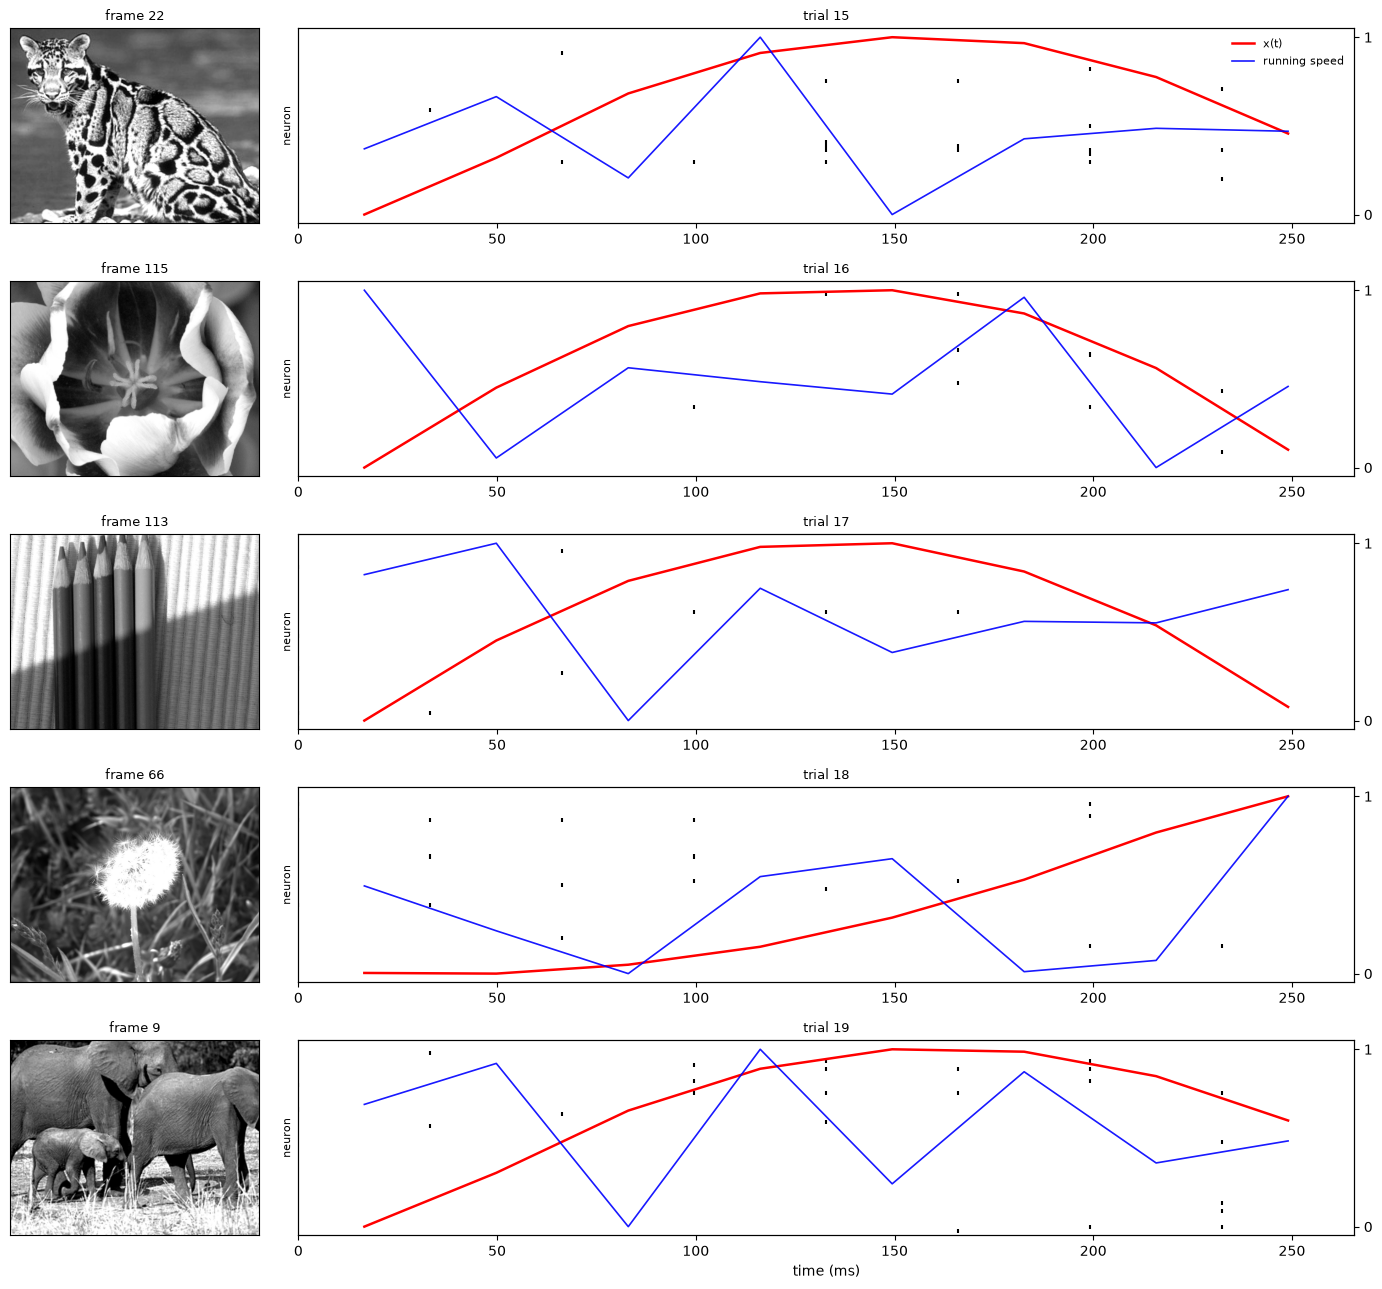

In [312]:
fig, axs = plot_natural_scenes_gpfa(
    fit=fit_natural_scenes,
    data_gpfa=data_natural_scenes,
    raw_data=data,
    n_trials=5,
    latent_dim=0,
    start_trial=15,
)
plt.show()

## 2. Evaluate drifiting gratings fit

In [313]:
fit_drifting_gratings = xval_drifting_gratings.fits[0]

In [314]:
def plot_drifting_gratings_gpfa(
    fit,
    data_gpfa,
    raw_data=None,
    n_trials=12,
    latent_dim=0,
    start_trial=0,
    figsize=(14, 2.6),
):
    """
    Plot drifting gratings trials as: raster + latent + speed plot and as title the orientation of the grating.
    """
    trial_ids = list(range(
        start_trial,
        min(start_trial + n_trials, len(fit.infRes["post_mean"]), data_gpfa.numTrials),
    ))

    ydim = data_gpfa.ydim  # nr of neurons
    T = data_gpfa.T  # number of time bins per trial
    trial_dur_ms = data_gpfa.trialDur  # rounded trial duration in milliseconds (this is a constant here)

    t_lat = (np.arange(T) + 0.5) * data_gpfa.binSize  # latent sample timestamps, bin-centered

    fig, axs = plt.subplots(
        len(trial_ids),
        1,
        figsize=(figsize[0], figsize[1] * len(trial_ids)),
        squeeze=False,
    )

    for r, tr in enumerate(trial_ids):
        trial = data_gpfa.data[tr]

        orientation = trial.get("parameter")
        speed = np.asarray(trial.get("running_speed", [])).reshape(-1)
        # bin-centered timestamps for speed, using speed's own (possibly different) sampling rate
        bin_width_speed = trial_dur_ms / speed.size
        t_speed = (np.arange(speed.size) + 0.5) * bin_width_speed

        ax = axs[r, 0]
        spike_times_ms = [np.asarray(st).reshape(-1) * 1000.0 for st in trial["spike_time"]]  # shape (n_neurons (Y), T)
        
        ax.eventplot(
            spike_times_ms,
            orientation="horizontal",
            colors="black",
        )
        ax.set_xlim(0, trial_dur_ms)
        ax.set_ylim(-1, ydim)
        ax.set_ylabel("neuron", fontsize=8)
        ax.set_yticks([])
        ax.set_title(f"trial {tr}, orientation={orientation}", fontsize=10)

        ax2 = ax.twinx()
        latent_norm = _robust_minmax(fit.infRes["post_mean"][tr][latent_dim, :])  # shape (T,)
        ax2.plot(t_lat, latent_norm, color="red", lw=1.8, label="x(t)")

        rs_norm = _robust_minmax(speed)
        ax2.plot(t_speed, rs_norm, color="blue", lw=1.2, alpha=0.9, label="running speed")

        ax2.set_ylim(-0.05, 1.05)
        ax2.set_yticks([0, 1])
        ax2.set_yticklabels(["0", "1"]) 
    
    
    fig.tight_layout()
    return fig, axs


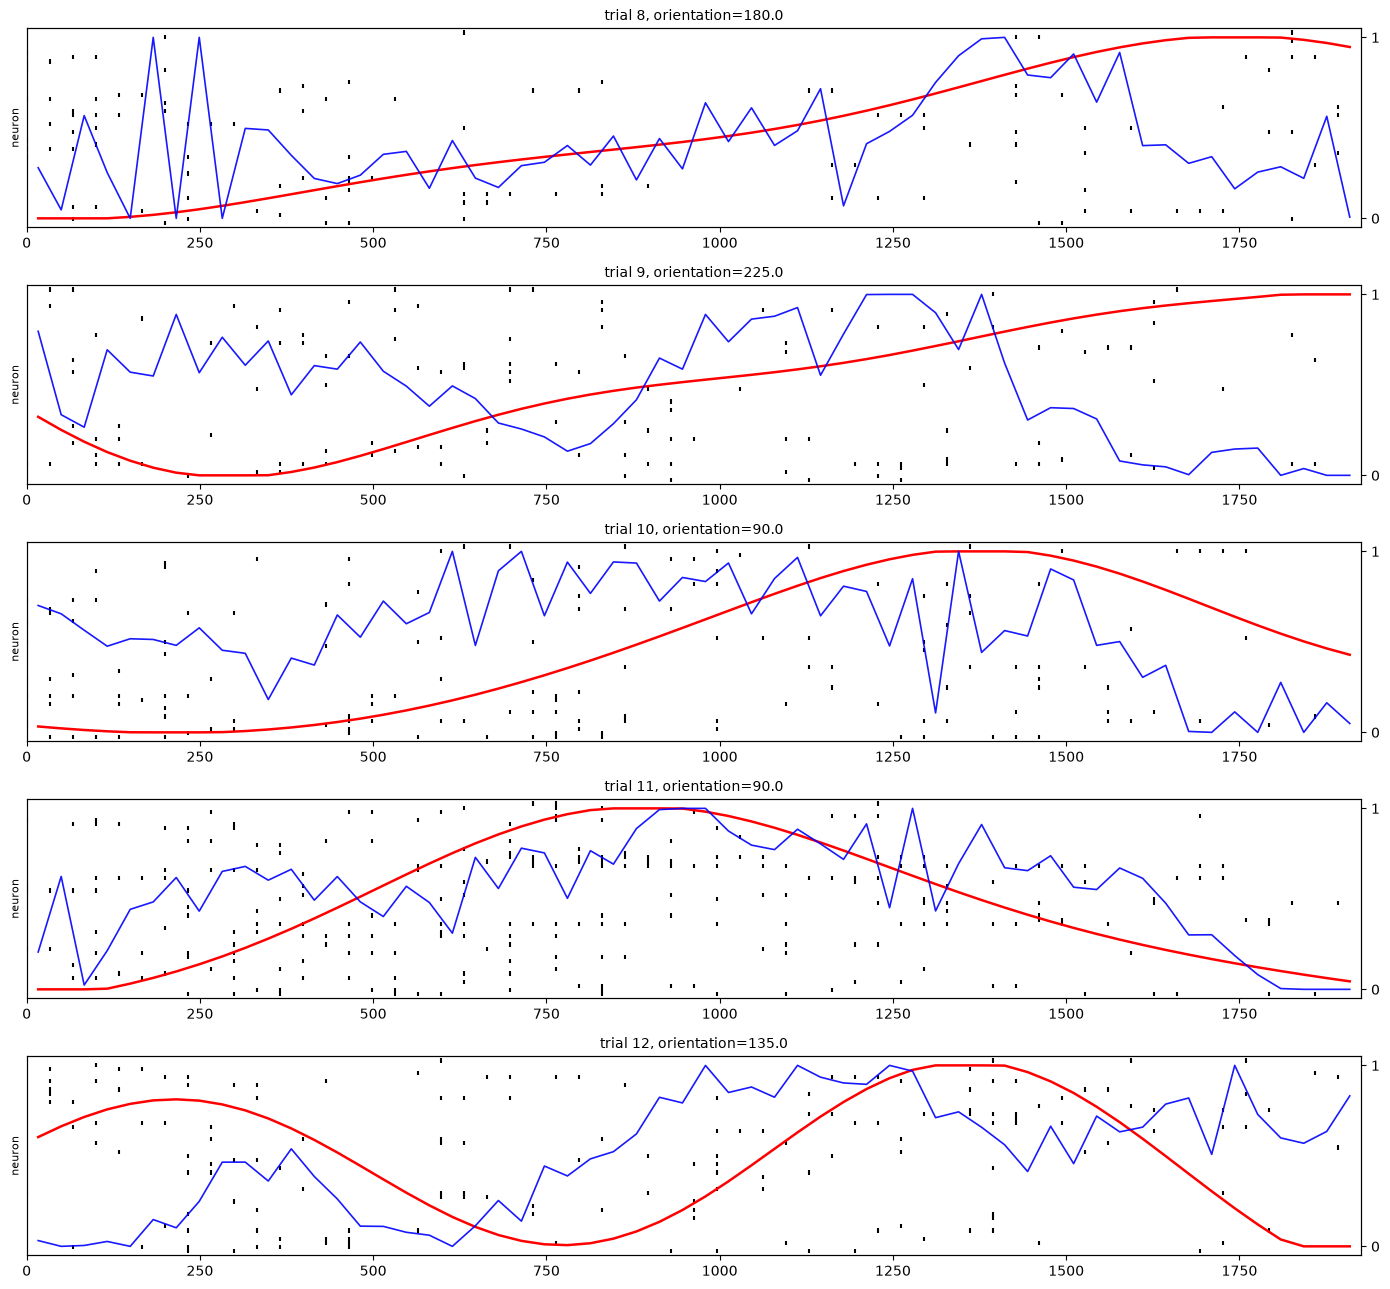

In [323]:
fig, axs = plot_drifting_gratings_gpfa(
    fit=fit_drifting_gratings,
    data_gpfa=data_drifitng_gratings,
    raw_data=data,
    n_trials=5,
    latent_dim=0,
    start_trial=8,
)